# 🎬 Phase 1: Data Cleaning & Preprocessing
## MovieLens 20M — Advanced Hybrid Recommender System

This notebook covers:
1. Loading all raw datasets
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Validation
4. Feature Engineering
5. Saving processed data

## 0. Imports & Configuration

In [29]:
import os
import sys
import warnings
import logging
import yaml
import json
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tqdm.notebook import tqdm
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ──────────────────────────────────────────────────────────
NOTEBOOK_DIR = Path().absolute()
PROJECT_ROOT = NOTEBOOK_DIR.parent
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
PROC_DIR     = PROJECT_ROOT / 'data' / 'processed'
MODEL_DIR    = PROJECT_ROOT / 'data' / 'models'
LOG_DIR      = PROJECT_ROOT / 'logs'

for d in [PROC_DIR, MODEL_DIR, LOG_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Config ─────────────────────────────────────────────────────────
with open(PROJECT_ROOT / 'utils' / 'config' / 'config.yaml') as f:
    CFG = yaml.safe_load(f)

MIN_USER_RATINGS  = CFG['data']['min_ratings_per_user']
MIN_MOVIE_RATINGS = CFG['data']['min_ratings_per_movie']
RANDOM_STATE      = CFG['data']['random_state']

# ── Logging ────────────────────────────────────────────────────────
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)s  %(message)s',
    handlers=[
        logging.FileHandler(LOG_DIR / 'phase1_cleaning.log'),
        logging.StreamHandler(sys.stdout)
    ]
)
log = logging.getLogger(__name__)

# ── NLTK downloads ─────────────────────────────────────────────────
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)

log.info('✅ Environment ready  |  Project root: %s', PROJECT_ROOT)

2026-03-06 22:08:55,396  INFO  ✅ Environment ready  |  Project root: D:\Movie Recommender System


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10

## 1. Load Raw Data

In [30]:
def load_csv(name: str, **kwargs) -> pd.DataFrame:
    """Load a CSV from raw dir with timing and row count."""
    path = RAW_DIR / name
    if not path.exists():
        log.warning('⚠️  File not found: %s  — skipping', path)
        return pd.DataFrame()
    t0 = datetime.now()
    df = pd.read_csv(path, **kwargs)
    elapsed = (datetime.now() - t0).total_seconds()
    log.info('Loaded %-22s  rows=%d  cols=%d  (%.1fs)', name, len(df), df.shape[1], elapsed)
    return df

# Core files
ratings_raw = load_csv(
    'rating.csv',
    dtype={'userId': 'int32', 'movieId': 'int32', 'rating': 'float32'},
    parse_dates=['timestamp']
)
movies_raw  = load_csv('movie.csv',  dtype={'movieId': 'int32'})
tags_raw    = load_csv('tag.csv',    dtype={'userId': 'int32', 'movieId': 'int32'})
links_raw   = load_csv('link.csv',   dtype={'movieId': 'int32'})

# Optional genome files (MovieLens 20M)
genome_scores = load_csv('genome_scores.csv', dtype={'movieId': 'int32', 'tagId': 'int32', 'relevance': 'float32'})
genome_tags   = load_csv('genome_tags.csv',   dtype={'tagId': 'int32'})

log.info('\n✅ All files loaded.')

2026-03-06 22:09:46,778  INFO  Loaded rating.csv              rows=20000263  cols=4  (51.4s)
2026-03-06 22:09:46,838  INFO  Loaded movie.csv               rows=27278  cols=3  (0.0s)
2026-03-06 22:09:47,403  INFO  Loaded tag.csv                 rows=465564  cols=4  (0.5s)
2026-03-06 22:09:47,534  INFO  Loaded link.csv                rows=27278  cols=3  (0.0s)
2026-03-06 22:09:50,237  INFO  Loaded genome_scores.csv       rows=11709768  cols=3  (2.7s)
2026-03-06 22:09:50,256  INFO  Loaded genome_tags.csv         rows=1128  cols=2  (0.0s)
2026-03-06 22:09:50,260  INFO  
✅ All files loaded.


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 33: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10

## 2. Exploratory Data Analysis (EDA)

In [31]:
# ── Quick shape overview ────────────────────────────────────────────
overview = {
    'Dataset':    ['rating', 'movie', 'tag', 'link', 'genome_scores', 'genome_tags'],
    'Rows':       [len(ratings_raw), len(movies_raw), len(tags_raw), len(links_raw),
                   len(genome_scores), len(genome_tags)],
    'Columns':    [ratings_raw.shape[1], movies_raw.shape[1], tags_raw.shape[1],
                   links_raw.shape[1], genome_scores.shape[1], genome_tags.shape[1]]
}
pd.DataFrame(overview).style.background_gradient(cmap='Blues', subset=['Rows'])

,Dataset,Rows,Columns
0,rating,20000263,4
1,movie,27278,3
2,tag,465564,4
3,link,27278,3
4,genome_scores,11709768,3
5,genome_tags,1128,2


In [32]:
print('=== RATINGS ===' )
display(ratings_raw.head(3))
print(f'\nUnique users  : {ratings_raw.userId.nunique():,}')
print(f'Unique movies  : {ratings_raw.movieId.nunique():,}')
print(f'Rating range  : {ratings_raw.rating.min()} – {ratings_raw.rating.max()}')
print(f'Missing values:\n{ratings_raw.isnull().sum()}')

=== RATINGS ===


,userId,movieId,rating,timestamp
0,1,2,3.5000,2005-04-02 23:53:47
1,1,29,3.5000,2005-04-02 23:31:16
2,1,32,3.5000,2005-04-02 23:33:39



Unique users  : 138,493
Unique movies  : 26,744
Rating range  : 0.5 – 5.0
Missing values:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [33]:
print('=== MOVIES ===')
display(movies_raw.head(5))
print(f'\nMissing values:\n{movies_raw.isnull().sum()}')

=== MOVIES ===


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Missing values:
movieId    0
title      0
genres     0
dtype: int64


2026-03-06 22:09:51,158  INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2026-03-06 22:09:51,161  INFO  Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.


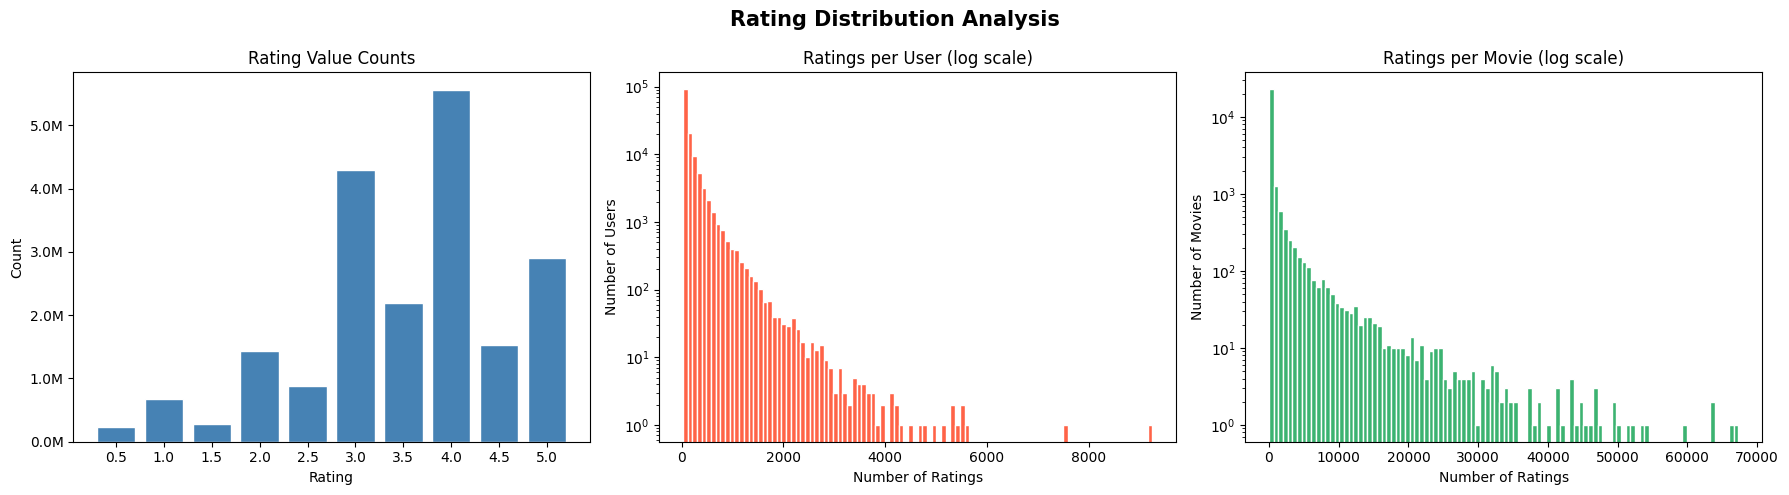

2026-03-06 22:09:53,931  INFO  EDA plot saved.


In [34]:
# ── Rating distribution ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Rating Distribution Analysis', fontsize=15, fontweight='bold')

# Rating counts
rating_counts = ratings_raw['rating'].value_counts().sort_index()
axes[0].bar(rating_counts.index.astype(str), rating_counts.values, color='steelblue', edgecolor='white')
axes[0].set_title('Rating Value Counts')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))

# Ratings per user
user_rating_counts = ratings_raw.groupby('userId').size()
axes[1].hist(user_rating_counts, bins=100, color='tomato', edgecolor='white', log=True)
axes[1].set_title('Ratings per User (log scale)')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Number of Users')

# Ratings per movie
movie_rating_counts = ratings_raw.groupby('movieId').size()
axes[2].hist(movie_rating_counts, bins=100, color='mediumseagreen', edgecolor='white', log=True)
axes[2].set_title('Ratings per Movie (log scale)')
axes[2].set_xlabel('Number of Ratings')
axes[2].set_ylabel('Number of Movies')

plt.tight_layout()
plt.savefig(PROC_DIR / 'eda_rating_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
log.info('EDA plot saved.')

In [35]:
# ── Genre analysis ──────────────────────────────────────────────────
all_genres = movies_raw['genres'].str.split('|').explode()
genre_counts = all_genres[all_genres != '(no genres listed)'].value_counts()

fig = px.bar(x=genre_counts.values, y=genre_counts.index,
             orientation='h', color=genre_counts.values,
             color_continuous_scale='Viridis',
             title='Movie Count by Genre',
             labels={'x': 'Count', 'y': 'Genre'})
fig.update_layout(height=500, showlegend=False)
fig.show()

In [36]:
# ── Year distribution ───────────────────────────────────────────────
movies_raw['year'] = movies_raw['title'].str.extract(r'\((\d{4})\)').astype('float32')
year_counts = movies_raw['year'].dropna().astype(int).value_counts().sort_index()

fig = px.area(x=year_counts.index, y=year_counts.values,
              title='Movies Released per Year',
              labels={'x': 'Year', 'y': 'Count'})
fig.update_traces(line_color='royalblue', fillcolor='rgba(65,105,225,0.2)')
fig.show()

## 3. Data Cleaning

In [37]:
log.info('Starting data cleaning...')

# ── 3.1 Clean RATINGS ──────────────────────────────────────────────
ratings = ratings_raw.copy()

# Drop duplicates (same user–movie pair, keep latest)
before = len(ratings)
ratings = ratings.sort_values('timestamp').drop_duplicates(subset=['userId', 'movieId'], keep='last')
log.info('Ratings: dropped %d duplicates', before - len(ratings))

# Drop any nulls
ratings.dropna(inplace=True)

# Convert timestamp to datetime
ratings['datetime'] = pd.to_datetime(ratings['timestamp'], unit='s')
ratings['year']     = ratings['datetime'].dt.year
ratings['month']    = ratings['datetime'].dt.month

# Validate rating range
valid_mask = ratings['rating'].between(0.5, 5.0)
log.info('Ratings outside [0.5, 5.0]: %d — removing', (~valid_mask).sum())
ratings = ratings[valid_mask].reset_index(drop=True)

log.info('Ratings after basic cleaning: %d rows', len(ratings))

2026-03-06 22:09:54,177  INFO  Starting data cleaning...
2026-03-06 22:10:01,620  INFO  Ratings: dropped 0 duplicates
2026-03-06 22:10:11,781  INFO  Ratings outside [0.5, 5.0]: 0 — removing
2026-03-06 22:10:12,896  INFO  Ratings after basic cleaning: 20000263 rows


In [38]:
# ── 3.2 Activity filter (cold-start removal) ───────────────────────
# Iterative filtering — run until stable
prev_len = -1
iteration = 0

while prev_len != len(ratings):
    prev_len = len(ratings)
    user_counts  = ratings['userId'].value_counts()
    movie_counts = ratings['movieId'].value_counts()
    active_users  = user_counts[user_counts  >= MIN_USER_RATINGS].index
    active_movies = movie_counts[movie_counts >= MIN_MOVIE_RATINGS].index
    ratings = ratings[ratings['userId'].isin(active_users) &
                      ratings['movieId'].isin(active_movies)]
    iteration += 1
    log.info('Iteration %d: %d rows | %d users | %d movies',
             iteration, len(ratings),
             ratings['userId'].nunique(),
             ratings['movieId'].nunique())

ratings = ratings.reset_index(drop=True)
log.info('✅ Ratings final: %d rows  |  %d users  |  %d movies',
         len(ratings), ratings['userId'].nunique(), ratings['movieId'].nunique())

2026-03-06 22:10:14,853  INFO  Iteration 1: 19964833 rows | 138493 users | 15451 movies
2026-03-06 22:10:16,658  INFO  Iteration 2: 19964039 rows | 138450 users | 15451 movies
2026-03-06 22:10:18,373  INFO  Iteration 3: 19963994 rows | 138450 users | 15446 movies
2026-03-06 22:10:19,557  INFO  Iteration 4: 19963994 rows | 138450 users | 15446 movies
2026-03-06 22:10:20,018  INFO  ✅ Ratings final: 19963994 rows  |  138450 users  |  15446 movies


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10

In [39]:
# ── 3.3 Clean MOVIES ───────────────────────────────────────────────
movies = movies_raw.copy()

# Extract year from title
movies['year'] = movies['title'].str.extract(r'\((\d{4})\)').astype('float32')

# Clean title (remove year suffix)
movies['title_clean'] = movies['title'].str.replace(r'\s*\(\d{4}\)\s*$', '', regex=True).str.strip()

# Handle missing genres
movies['genres'] = movies['genres'].replace('(no genres listed)', np.nan)

# Genre list column
movies['genre_list'] = movies['genres'].fillna('').str.split('|')
movies['n_genres']   = movies['genre_list'].apply(len)

# Only keep movies present in filtered ratings
valid_movie_ids = ratings['movieId'].unique()
movies = movies[movies['movieId'].isin(valid_movie_ids)].reset_index(drop=True)

log.info('✅ Movies final: %d rows', len(movies))
movies.head(3)

2026-03-06 22:10:20,363  INFO  ✅ Movies final: 15446 rows


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10

,movieId,title,genres,year,title_clean,genre_list,n_genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995.0000,Toy Story,"[Adventure, Animation, Children, Comedy, Fantasy]",5
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995.0000,Jumanji,"[Adventure, Children, Fantasy]",3
2,3,Grumpier Old Men (1995),Comedy|Romance,1995.0000,Grumpier Old Men,"[Comedy, Romance]",2


In [40]:
# ── 3.4 Clean TAGS ─────────────────────────────────────────────────
if not tags_raw.empty:
    tags = tags_raw.copy()
    tags.dropna(subset=['tag'], inplace=True)
    tags['tag'] = tags['tag'].str.lower().str.strip()
    # Remove very short / numeric-only tags
    tags = tags[tags['tag'].str.len() > 2]
    tags = tags[~tags['tag'].str.fullmatch(r'\d+')]
    # Only keep tags for valid movies/users
    valid_users = ratings['userId'].unique()
    tags = tags[tags['userId'].isin(valid_users) & tags['movieId'].isin(valid_movie_ids)]
    tags = tags.reset_index(drop=True)
    log.info('✅ Tags final: %d rows', len(tags))
else:
    tags = pd.DataFrame(columns=['userId', 'movieId', 'tag', 'timestamp'])
    log.warning('Tags file not found — skipping')

2026-03-06 22:10:21,268  INFO  ✅ Tags final: 447878 rows


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10

## 4. Feature Engineering

In [41]:
# ── 4.1 User features ──────────────────────────────────────────────
log.info('Building user features...')

user_features = ratings.groupby('userId').agg(
    n_ratings        = ('rating', 'count'),
    mean_rating      = ('rating', 'mean'),
    std_rating       = ('rating', 'std'),
    min_rating       = ('rating', 'min'),
    max_rating       = ('rating', 'max'),
    first_rating_ts  = ('timestamp', 'min'),
    last_rating_ts   = ('timestamp', 'max'),
).reset_index()

user_features['std_rating']    = user_features['std_rating'].fillna(0)
user_features['activity_days'] = ((user_features['last_rating_ts'] - user_features['first_rating_ts']) / 86400).round(1)
user_features['rating_range']  = user_features['max_rating'] - user_features['min_rating']

log.info('User features shape: %s', user_features.shape)
user_features.describe()

2026-03-06 22:10:21,296  INFO  Building user features...
2026-03-06 22:10:22,878  INFO  User features shape: (138450, 10)


,userId,n_ratings,mean_rating,std_rating,min_rating,max_rating,first_rating_ts,last_rating_ts,activity_days,rating_range
count,138450.0000,138450.0000,138450.0000,138450.0000,138450.0000,138450.0000,138450,138450,138450,138450.0000
mean,69245.5581,144.1964,3.6275,0.9525,1.2358,4.9670,2003-08-16 16:43:02.487518848,2004-02-29 06:41:59.876374272,0 days 00:03:16.582608666,3.7312
min,1.0000,20.0000,0.5000,0.0000,0.5000,0.5000,1995-01-09 11:46:44,1996-02-23 12:56:00,0 days 00:00:00,0.0000
25%,34623.2500,35.0000,3.3696,0.7870,0.5000,5.0000,1997-11-05 17:21:52,1998-05-22 11:46:59,0 days 00:00:00.010393518,3.0000
50%,69245.5000,68.0000,3.6539,0.9300,1.0000,5.0000,2002-09-12 23:05:47.500000,2003-07-06 03:21:24.500000,0 days 00:00:00.039317129,4.0000
75%,103868.7500,155.0000,3.9231,1.0953,2.0000,5.0000,2008-06-30 21:10:33.500000,2009-04-06 12:22:08.750000128,0 days 00:00:30.555700231,4.0000
max,138493.0000,8017.0000,5.0000,2.3085,5.0000,5.0000,2015-03-31 04:12:42,2015-03-31 06:40:02,0 days 01:46:45.271076388,4.5000
std,39980.3106,228.1950,0.4429,0.2381,0.7217,0.1678,NaN,NaN,0 days 00:10:27.637963905,0.7413


In [42]:
# ── 4.2 Movie features ─────────────────────────────────────────────
log.info('Building movie features...')

movie_features = ratings.groupby('movieId').agg(
    n_ratings   = ('rating', 'count'),
    mean_rating = ('rating', 'mean'),
    std_rating  = ('rating', 'std'),
    n_raters    = ('userId', 'nunique'),
).reset_index()
movie_features['std_rating'] = movie_features['std_rating'].fillna(0)

# Bayesian average rating (dampens low-count movies)
C = movie_features['n_ratings'].mean()          # avg ratings count
m = movie_features['mean_rating'].mean()        # global mean
movie_features['bayesian_avg'] = (
    (movie_features['n_ratings'] * movie_features['mean_rating'] + C * m)
    / (movie_features['n_ratings'] + C)
)

# Merge with movie metadata
movie_features = movie_features.merge(movies[['movieId', 'title_clean', 'genres', 'genre_list', 'year', 'n_genres']],
                                      on='movieId', how='left')
log.info('Movie features shape: %s', movie_features.shape)
movie_features.head(3)

2026-03-06 22:10:22,972  INFO  Building movie features...
2026-03-06 22:10:27,151  INFO  Movie features shape: (15446, 11)


,movieId,n_ratings,mean_rating,std_rating,n_raters,bayesian_avg,title_clean,genres,genre_list,year,n_genres
0,1,49695,3.9212,0.8890,49695,3.9036,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",1995.0000,5
1,2,22243,3.2120,0.9511,22243,3.2126,Jumanji,Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",1995.0000,3
2,3,12733,3.1511,1.0065,12733,3.1578,Grumpier Old Men,Comedy|Romance,"[Comedy, Romance]",1995.0000,2


In [43]:
# ── 4.3 Content feature: aggregate tags per movie ──────────────────
log.info('Building tag-based content features...')

if not tags.empty:
    movie_tags = tags.groupby('movieId')['tag'].apply(lambda x: ' '.join(x)).reset_index()
    movie_tags.columns = ['movieId', 'tags_text']
else:
    movie_tags = pd.DataFrame({'movieId': valid_movie_ids, 'tags_text': ''})

# Incorporate genome tags if available
if not genome_scores.empty and not genome_tags.empty:
    log.info('Merging genome relevance scores...')
    # Keep top-5 most relevant tags per movie
    top_genome = (
        genome_scores[genome_scores['movieId'].isin(valid_movie_ids)]
        .merge(genome_tags, on='tagId')
        .sort_values('relevance', ascending=False)
        .groupby('movieId')
        .head(5)
        .groupby('movieId')['tag']
        .apply(lambda x: ' '.join(x.tolist()))
        .reset_index()
    )
    top_genome.columns = ['movieId', 'genome_tags']
    movie_tags = movie_tags.merge(top_genome, on='movieId', how='left')
    movie_tags['tags_text'] = (movie_tags['tags_text'].fillna('') + ' ' +
                               movie_tags['genome_tags'].fillna('')).str.strip()
    log.info('Genome tags merged.')

log.info('Movie tags shape: %s', movie_tags.shape)

2026-03-06 22:10:27,173  INFO  Building tag-based content features...
2026-03-06 22:10:27,768  INFO  Merging genome relevance scores...
2026-03-06 22:10:35,844  INFO  Genome tags merged.
2026-03-06 22:10:35,845  INFO  Movie tags shape: (13731, 3)


In [44]:
# ── 4.4 Build master content document per movie ────────────────────
log.info('Building master content document...')

STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()

def build_content_doc(row) -> str:
    """Combine genres + tags into a single text document for TF-IDF."""
    parts = []
    # Genres (repeat 3x to upweight)
    if isinstance(row.get('genres'), str):
        genre_tokens = row['genres'].lower().replace('|', ' ').replace('-', '')
        parts.extend([genre_tokens] * 3)
    # Tags
    if isinstance(row.get('tags_text'), str) and row['tags_text']:
        tokens = row['tags_text'].lower().split()
        filtered = [stemmer.stem(t) for t in tokens if t not in STOP_WORDS and len(t) > 2]
        parts.append(' '.join(filtered))
    return ' '.join(parts).strip()

content_df = movie_features[['movieId', 'title_clean', 'genres', 'year']].merge(
    movie_tags[['movieId', 'tags_text']], on='movieId', how='left'
)
content_df['tags_text'] = content_df['tags_text'].fillna('')

tqdm.pandas(desc='Building content docs')
content_df['content_doc'] = content_df.progress_apply(build_content_doc, axis=1)

log.info('Content docs built. Sample:\n%s', content_df['content_doc'].iloc[:2].to_string())

2026-03-06 22:10:35,863  INFO  Building master content document...


Building content docs:   0%|          | 0/15446 [00:00<?, ?it/s]

2026-03-06 22:10:54,784  INFO  Content docs built. Sample:
0    adventure animation children comedy fantasy adventure animation children com...
1    adventure children fantasy adventure children fantasy adventure children fan...


In [45]:
# ── 4.5 Encode user & movie IDs to contiguous integers ─────────────
log.info('Creating ID encoders...')

unique_users  = sorted(ratings['userId'].unique())
unique_movies = sorted(ratings['movieId'].unique())

user2idx  = {uid: idx for idx, uid in enumerate(unique_users)}
movie2idx = {mid: idx for idx, mid in enumerate(unique_movies)}
idx2user  = {v: k for k, v in user2idx.items()}
idx2movie = {v: k for k, v in movie2idx.items()}

ratings['user_idx']  = ratings['userId'].map(user2idx).astype('int32')
ratings['movie_idx'] = ratings['movieId'].map(movie2idx).astype('int32')

N_USERS  = len(unique_users)
N_MOVIES = len(unique_movies)

log.info('N_USERS=%d  N_MOVIES=%d', N_USERS, N_MOVIES)
print(f'Sparsity: {1 - len(ratings) / (N_USERS * N_MOVIES):.4%}')

2026-03-06 22:10:54,806  INFO  Creating ID encoders...
2026-03-06 22:10:56,352  INFO  N_USERS=138450  N_MOVIES=15446
Sparsity: 99.0664%


## 5. Train / Validation / Test Split

In [46]:
from sklearn.model_selection import train_test_split

# Temporal split — use last 10% of each user's ratings as test
log.info('Creating temporal train/val/test splits...')

ratings_sorted = ratings.sort_values(['userId', 'timestamp'])

def temporal_split(group, test_frac=0.1, val_frac=0.1):
    n = len(group)
    n_test = max(1, int(n * test_frac))
    n_val  = max(1, int(n * val_frac))
    test  = group.iloc[-n_test:]
    val   = group.iloc[-(n_test + n_val):-n_test]
    train = group.iloc[:-(n_test + n_val)]
    return train, val, test

trains, vals, tests = [], [], []
for _, grp in tqdm(ratings_sorted.groupby('userId'), desc='Splitting users'):
    tr, v, te = temporal_split(grp)
    trains.append(tr); vals.append(v); tests.append(te)

train_df = pd.concat(trains).reset_index(drop=True)
val_df   = pd.concat(vals).reset_index(drop=True)
test_df  = pd.concat(tests).reset_index(drop=True)

log.info('Train: %d  |  Val: %d  |  Test: %d', len(train_df), len(val_df), len(test_df))
print(f'Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}')

2026-03-06 22:10:56,376  INFO  Creating temporal train/val/test splits...


Splitting users:   0%|          | 0/138450 [00:00<?, ?it/s]

2026-03-06 22:13:00,162  INFO  Train: 16087404  |  Val: 1938295  |  Test: 1938295
Train: 16,087,404  |  Val: 1,938,295  |  Test: 1,938,295


## 6. Save Processed Data

In [47]:
log.info('Saving all processed data...')

# Parquet (fast, compressed)
train_df.to_parquet(PROC_DIR / 'train.parquet',         index=False)
val_df.to_parquet(PROC_DIR   / 'val.parquet',           index=False)
test_df.to_parquet(PROC_DIR  / 'test.parquet',          index=False)
ratings.to_parquet(PROC_DIR  / 'ratings_clean.parquet', index=False)
movies.to_parquet(PROC_DIR   / 'movies_clean.parquet',  index=False)

movie_features.to_parquet(PROC_DIR / 'movie_features.parquet', index=False)
user_features.to_parquet(PROC_DIR  / 'user_features.parquet',  index=False)
content_df.to_parquet(PROC_DIR     / 'content_docs.parquet',   index=False)

# Encoders as JSON
with open(PROC_DIR / 'encoders.json', 'w') as f:
    json.dump({
        'user2idx':  {str(k): int(v) for k, v in user2idx.items()},
        'movie2idx': {str(k): int(v) for k, v in movie2idx.items()},
        'idx2user':  {str(k): int(v) for k, v in idx2user.items()},
        'idx2movie': {str(k): int(v) for k, v in idx2movie.items()},
        'n_users':   int(N_USERS),
        'n_movies':  int(N_MOVIES)
    }, f)

log.info('✅ All data saved to %s', PROC_DIR)

# Summary
print('\n' + '='*55)
print(' PHASE 1 COMPLETE — Processed Data Summary')
print('='*55)
for f in sorted(PROC_DIR.glob('*')):
    size_mb = f.stat().st_size / 1024**2
    print(f'  {f.name:<40}  {size_mb:6.2f} MB')
print('='*55)

2026-03-06 22:13:00,183  INFO  Saving all processed data...
2026-03-06 22:13:13,497  INFO  ✅ All data saved to D:\Movie Recommender System\data\processed

 PHASE 1 COMPLETE — Processed Data Summary
  content_docs.parquet                        4.86 MB
  eda_rating_distribution.png                 0.07 MB
  encoders.json                               4.76 MB
  movie_features.parquet                      0.78 MB
  movies_clean.parquet                        0.77 MB
  ratings_clean.parquet                     332.52 MB
  test.parquet                               39.75 MB
  train.parquet                             260.12 MB
  user_features.parquet                       5.65 MB
  val.parquet                                38.66 MB


--- Logging error ---
Traceback (most recent call last):
  File "C:\Users\khana\anaconda3\Lib\logging\__init__.py", line 1154, in emit
    stream.write(msg + self.terminator)
    ~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\khana\anaconda3\Lib\encodings\cp1252.py", line 19, in encode
    return codecs.charmap_encode(input,self.errors,encoding_table)[0]
           ~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeEncodeError: 'charmap' codec can't encode character '\u2705' in position 31: character maps to <undefined>
Call stack:
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 198, in _run_module_as_main
    return _run_code(code, main_globals, None,
  File "C:\Users\khana\anaconda3\Lib\runpy.py", line 88, in _run_code
    exec(code, run_globals)
  File "C:\Users\khana\anaconda3\Lib\site-packages\ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "C:\Users\khana\anaconda3\Lib\site-packages\traitlets\config\application.py", line 10